# HW14.ipynb

Домашняя работа по теме: эмбеддинги, индекс `FAISS`, оценка retrieval, обновление базы знаний и mini-RAG.

В ноутбуке:
- загружается небольшая база знаний по Flask;
- документы разбиваются на чанки;
- строятся векторные представления;
- собирается индекс `FAISS`;
- считается качество retrieval на контрольных запросах;
- проводится небольшой эксперимент по `chunk_size`;
- демонстрируется обновление базы знаний и переиндексация;
- собирается простой mini-RAG с возвратом источников.


In [1]:
# Если faiss не установлен, ставим faiss-cpu прямо из ноутбука.
import sys
import subprocess
import importlib

def ensure_package(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        return importlib.import_module(import_name)

faiss = ensure_package("faiss", "faiss-cpu")


In [2]:
from pathlib import Path
import json
import math
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path.cwd()
ART_DIR = BASE_DIR / "artifacts"
KB_DIR = BASE_DIR / "knowledge_base"
ART_DIR.mkdir(exist_ok=True)
KB_DIR.mkdir(exist_ok=True)

print("Seed =", SEED)
print("faiss version =", getattr(faiss, "__version__", "unknown"))


Seed = 42
faiss version = 1.13.2


## 1. База знаний и первичный анализ

База знаний посвящена Flask-разработке. Это компактный тематический набор документов, на котором удобно показывать retrieval и mini-RAG: вопросы обычно соотносятся с конкретными темами, а ответы можно проверять вручную.


In [3]:
initial_docs_path = KB_DIR / "knowledge_base_initial.json"
updates_docs_path = KB_DIR / "knowledge_base_updates.json"

docs = pd.read_json(initial_docs_path).to_dict("records")
new_docs = pd.read_json(updates_docs_path).to_dict("records")

print("Число исходных документов:", len(docs))
print("Число новых документов для обновления:", len(new_docs))

docs_df = pd.DataFrame(docs)
docs_df[["source_id", "title"]]


Число исходных документов: 12
Число новых документов для обновления: 3


,source_id,title
0,doc_intro_app_structure,Введение во Flask и структура приложения
1,doc_config_secrets,Конфигурация и секреты во Flask
2,doc_routing_views,Маршруты и view-функции во Flask
3,doc_jinja_templates,Шаблоны Jinja и передача данных в HTML
4,doc_forms_validation,Формы и валидация пользовательского ввода
5,doc_sessions_auth,"Сессии, cookies и базовая аутентификация"
6,doc_blueprints,Blueprints и модульная структура приложения
7,doc_sqlalchemy_models,Работа с базой данных и SQLAlchemy
8,doc_rest_api_json,REST API и JSON-ответы во Flask
9,doc_testing_pytest,Тестирование Flask-приложения


In [4]:
for i, doc in enumerate(docs[:3], start=1):
    print("=" * 80)
    print(f"Пример документа {i}: {doc['title']} ({doc['source_id']})")
    print(doc["text"][:600], "...")
    print()


Пример документа 1: Введение во Flask и структура приложения (doc_intro_app_structure)
Flask — это лёгкий Python-фреймворк для веб-приложений и API. Его часто выбирают, когда нужен прозрачный и понятный стек без тяжёлой магии. Базовое приложение обычно создаётся через объект Flask, а маршруты регистрируются декораторами route.

Для учебных и небольших проектов можно начать с одного файла app.py, но по мере роста приложения полезно выделять отдельные модули для маршрутов, конфигурации, моделей и сервисной логики. Это упрощает сопровождение и тестирование.

Даже в маленьком проекте полезно заранее договориться о структуре каталогов: templates для HTML-шаблонов, static для CSS и Ja ...

Пример документа 2: Конфигурация и секреты во Flask (doc_config_secrets)
Конфигурацию Flask-приложения удобно хранить в app.config. В неё выносят SECRET_KEY, URI базы данных, флаги отладки и прочие параметры среды. Важно не хардкодить секреты прямо в исходном коде.

Для локальной разработки часто использую

## 2. Чанкинг документов

Используем простой воспроизводимый чанкинг: разбиваем текст на перекрывающиеся фрагменты по словам. В обязательной части этого достаточно: нам не нужен сложный semantic chunking, важно лишь получить разумные фрагменты для retrieval.


In [5]:
def normalize_text(s):
    return re.sub(r"\s+", " ", s).strip()

def chunk_text(text, chunk_size=320, overlap=80):
    words = normalize_text(text).split()
    chunks = []
    start = 0

    while start < len(words):
        cur_words = []
        cur_len = 0
        i = start

        while i < len(words):
            w = words[i]
            add = len(w) + (1 if cur_words else 0)
            if cur_words and cur_len + add > chunk_size:
                break
            cur_words.append(w)
            cur_len += add
            i += 1

        if not cur_words:
            cur_words = [words[start]]
            i = start + 1

        chunks.append(" ".join(cur_words))

        if i >= len(words):
            break

        back = 0
        j = i - 1
        while j > start and back < overlap:
            back += len(words[j]) + 1
            j -= 1
        start = max(start + 1, j + 1)

    return chunks

def build_chunks(documents, chunk_size=320, overlap=80):
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk in enumerate(chunks):
            rows.append({
                "source_id": doc["source_id"],
                "title": doc["title"],
                "chunk_id": f"{doc['source_id']}::chunk_{idx}",
                "chunk_index": idx,
                "text": chunk,
                "embed_text": f"{doc['title']}. {chunk}",
            })
    return pd.DataFrame(rows)

chunk_size_main = 320
overlap_main = 80

chunks_df = build_chunks(docs, chunk_size=chunk_size_main, overlap=overlap_main)
print("Число чанков:", len(chunks_df))
chunks_df.head()


Число чанков: 36


,source_id,title,chunk_id,chunk_index,text,embed_text
0,doc_intro_app_structure,Введение во Flask и структура приложения,doc_intro_app_structure::chunk_0,0,Flask — это лёгкий Python-фреймворк для веб-пр...,Введение во Flask и структура приложения. Flas...
1,doc_intro_app_structure,Введение во Flask и структура приложения,doc_intro_app_structure::chunk_1,1,route. Для учебных и небольших проектов можно ...,Введение во Flask и структура приложения. rout...
2,doc_intro_app_structure,Введение во Flask и структура приложения,doc_intro_app_structure::chunk_2,2,тестирование. Даже в маленьком проекте полезно...,Введение во Flask и структура приложения. тест...
3,doc_config_secrets,Конфигурация и секреты во Flask,doc_config_secrets::chunk_0,0,Конфигурацию Flask-приложения удобно хранить в...,Конфигурация и секреты во Flask. Конфигурацию ...
4,doc_config_secrets,Конфигурация и секреты во Flask,doc_config_secrets::chunk_1,1,.env или переменные окружения. Тогда приложени...,Конфигурация и секреты во Flask. .env или пере...


In [6]:
sample_doc_id = "doc_deployment_gunicorn_nginx"
sample_doc = next(d for d in docs if d["source_id"] == sample_doc_id)
sample_chunks = build_chunks([sample_doc], chunk_size=chunk_size_main, overlap=overlap_main)

print("Документ:", sample_doc["title"])
for _, row in sample_chunks.iterrows():
    print("-" * 80)
    print(row["chunk_id"])
    print(row["text"])


Документ: Развёртывание Flask через Gunicorn и Nginx
--------------------------------------------------------------------------------
doc_deployment_gunicorn_nginx::chunk_0
В production Flask-приложение обычно не запускают встроенным development server. Вместо этого используют WSGI-сервер, например Gunicorn, а перед ним ставят reverse proxy, например Nginx. Такая схема лучше подходит для боевой нагрузки. Gunicorn управляет воркерами Python-процесса, а Nginx принимает внешние подключения,
--------------------------------------------------------------------------------
doc_deployment_gunicorn_nginx::chunk_1
Gunicorn управляет воркерами Python-процесса, а Nginx принимает внешние подключения, может раздавать статику и проксировать запросы в приложение. Это упрощает балансировку, TLS и обработку заголовков на уровне веб-сервера. При деплое важно настроить переменные окружения, systemd unit или контейнер, а также логирование
-------------------------------------------------------------------

## 3. Эмбеддинги и индекс FAISS

В качестве векторизации используем `TF-IDF` по словам и биграммам. После L2-нормализации можно использовать `FAISS IndexFlatIP`, а inner product на нормализованных векторах будет соответствовать cosine similarity.


In [7]:
def build_faiss_index(chunks_df):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=6000)
    X = vectorizer.fit_transform(chunks_df["embed_text"]).astype(np.float32)
    X = normalize(X, norm="l2", copy=False)
    dense = X.toarray().astype("float32")

    index = faiss.IndexFlatIP(dense.shape[1])
    index.add(dense)
    return vectorizer, index, dense

def search(query, vectorizer, index, chunks_df, top_k=3):
    q = vectorizer.transform([query]).astype(np.float32)
    q = normalize(q, norm="l2", copy=False)
    q_dense = q.toarray().astype("float32")

    scores, idx = index.search(q_dense, top_k)
    results = chunks_df.iloc[idx[0]].copy().reset_index(drop=True)
    results["score"] = scores[0]
    return results

def dedup_preserve(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

vectorizer, index, dense = build_faiss_index(chunks_df)
top_k_main = 3
print("FAISS index ntotal =", index.ntotal)


FAISS index ntotal = 36


In [8]:
example_queries = [
    "Как сгруппировать маршруты по разделам приложения?",
    "Какой паттерн помогает избежать повторной отправки формы?",
    "Как разворачивать Flask за Gunicorn и Nginx?",
    "Как вернуть JSON-ответ клиенту?",
    "Как вынести секреты из исходного кода?",
]

for q in example_queries:
    print("=" * 100)
    print("QUERY:", q)
    res = search(q, vectorizer, index, chunks_df, top_k=3)
    print(res[["source_id", "score"]])
    print("TOP TEXT:", res.loc[0, "text"])
    print()


QUERY: Как сгруппировать маршруты по разделам приложения?
               source_id     score
0      doc_routing_views  0.125898
1         doc_blueprints  0.121969
2  doc_sqlalchemy_models  0.078233
TOP TEXT: приложение растёт, десятки маршрутов в одном файле становятся неудобными. Тогда маршруты выносят в отдельные модули и группируют по предметным областям, а для подключения используют blueprints.

QUERY: Какой паттерн помогает избежать повторной отправки формы?
              source_id     score
0  doc_forms_validation  0.304570
1  doc_forms_validation  0.263117
2   doc_jinja_templates  0.047922
TOP TEXT: чисел и другие ограничения. Во Flask для удобной работы с формами часто используют Flask-WTF или собственные функции валидации. После отправки формы приложение может либо повторно показать страницу с ошибками, либо сохранить данные и сделать redirect, чтобы избежать повторной отправки при обновлении страницы. Полезный

QUERY: Как разворачивать Flask за Gunicorn и Nginx?
             

## 4. Контрольные запросы и оценка retrieval

Для оценки retrieval используем небольшой набор контрольных запросов с заранее заданными релевантными источниками. Считаем минимум `hit@k` и `recall@k`, дополнительно — `MRR@k`.


In [9]:
queries = [
    {"query": "Как разделить большое Flask-приложение на несколько модулей с маршрутами?", "expected_sources": ["doc_blueprints"]},
    {"query": "Как передать данные из view-функции в HTML-шаблон?", "expected_sources": ["doc_jinja_templates"]},
    {"query": "Чем лучше запускать Flask в production за reverse proxy?", "expected_sources": ["doc_deployment_gunicorn_nginx"]},
    {"query": "Где хранить SECRET_KEY и другие секреты приложения?", "expected_sources": ["doc_config_secrets"]},
    {"query": "Как тестировать маршруты и JSON API во Flask?", "expected_sources": ["doc_testing_pytest", "doc_rest_api_json"]},
    {"query": "Как работать с формами и избежать повторной отправки после POST?", "expected_sources": ["doc_forms_validation"]},
    {"query": "Для чего нужен Flask-Login и где хранится сессия пользователя?", "expected_sources": ["doc_sessions_auth"]},
    {"query": "Как настроить ORM и миграции для базы данных во Flask?", "expected_sources": ["doc_sqlalchemy_models"]},
    {"query": "Как логировать ошибки и отправлять логи в мониторинг?", "expected_sources": ["doc_logging_monitoring"]},
    {"query": "Как вернуть JSON и правильно выставлять HTTP-коды ответа?", "expected_sources": ["doc_rest_api_json"]},
]

rows = []
for item in queries:
    res = search(item["query"], vectorizer, index, chunks_df, top_k=top_k_main)
    retrieved_sources = dedup_preserve(res["source_id"].tolist())
    expected = item["expected_sources"]

    hit = int(any(s in retrieved_sources[:top_k_main] for s in expected))
    recall = sum(s in retrieved_sources[:top_k_main] for s in expected) / len(expected)

    rank = ""
    for i, s in enumerate(retrieved_sources[:top_k_main], start=1):
        if s in expected:
            rank = i
            break

    rows.append({
        "query": item["query"],
        "expected_source": " | ".join(expected),
        "retrieved_sources": " | ".join(retrieved_sources[:top_k_main]),
        "hit_at_k": hit,
        "recall_at_k": recall,
        "rank_of_first_relevant": rank,
    })

retrieval_eval = pd.DataFrame(rows)
hit_at_k = float(retrieval_eval["hit_at_k"].mean())
recall_at_k = float(retrieval_eval["recall_at_k"].mean())
mrr_at_k = float(np.mean([1 / x if x != "" else 0 for x in retrieval_eval["rank_of_first_relevant"]]))

print("hit@3 =", round(hit_at_k, 3))
print("recall@3 =", round(recall_at_k, 3))
print("MRR@3 =", round(mrr_at_k, 3))

retrieval_eval


hit@3 = 1.0
recall@3 = 0.95
MRR@3 = 1.0


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant
0,Как разделить большое Flask-приложение на неск...,doc_blueprints,doc_blueprints | doc_routing_views | doc_deplo...,1,1.0,1
1,Как передать данные из view-функции в HTML-шаб...,doc_jinja_templates,doc_jinja_templates | doc_routing_views,1,1.0,1
2,Чем лучше запускать Flask в production за reve...,doc_deployment_gunicorn_nginx,doc_deployment_gunicorn_nginx | doc_jinja_temp...,1,1.0,1
3,Где хранить SECRET_KEY и другие секреты прилож...,doc_config_secrets,doc_config_secrets | doc_forms_validation,1,1.0,1
4,Как тестировать маршруты и JSON API во Flask?,doc_testing_pytest | doc_rest_api_json,doc_rest_api_json | doc_routing_views,1,0.5,1
5,Как работать с формами и избежать повторной от...,doc_forms_validation,doc_forms_validation | doc_config_secrets,1,1.0,1
6,Для чего нужен Flask-Login и где хранится сесс...,doc_sessions_auth,doc_sessions_auth | doc_intro_app_structure,1,1.0,1
7,Как настроить ORM и миграции для базы данных в...,doc_sqlalchemy_models,doc_sqlalchemy_models | doc_config_secrets,1,1.0,1
8,Как логировать ошибки и отправлять логи в мони...,doc_logging_monitoring,doc_logging_monitoring,1,1.0,1
9,Как вернуть JSON и правильно выставлять HTTP-к...,doc_rest_api_json,doc_rest_api_json | doc_testing_pytest,1,1.0,1


## 5. Небольшой эксперимент по параметрам retrieval

Сравним два значения `chunk_size`: `320` и `480`. Это простой и понятный способ посмотреть, меняется ли качество retrieval при более локальных или более крупных фрагментах.


In [10]:
experiment_results = []
for cs in [320, 480]:
    chunks_tmp = build_chunks(docs, chunk_size=cs, overlap=80)
    vec_tmp, index_tmp, _ = build_faiss_index(chunks_tmp)

    hits, recalls = [], []
    for item in queries:
        res = search(item["query"], vec_tmp, index_tmp, chunks_tmp, top_k=3)
        retrieved_sources = dedup_preserve(res["source_id"].tolist())
        expected = item["expected_sources"]

        hits.append(int(any(s in retrieved_sources[:3] for s in expected)))
        recalls.append(sum(s in retrieved_sources[:3] for s in expected) / len(expected))

    experiment_results.append({
        "chunk_size": cs,
        "overlap": 80,
        "num_chunks": len(chunks_tmp),
        "hit_at_3": float(np.mean(hits)),
        "recall_at_3": float(np.mean(recalls)),
    })

experiment_df = pd.DataFrame(experiment_results)
experiment_df


,chunk_size,overlap,num_chunks,hit_at_3,recall_at_3
0,320,80,36,1.0,0.95
1,480,80,24,1.0,0.95


## 6. Обновление базы знаний и переиндексация

Добавляем 3 новых документа: про кэширование, rate limiting и варианты почти realtime-обновлений. Затем полностью повторяем чанкинг, векторизацию и построение индекса.


In [11]:
docs_updated = docs + new_docs

chunks_before = build_chunks(docs, chunk_size=chunk_size_main, overlap=overlap_main)
vec_before, index_before, _ = build_faiss_index(chunks_before)

chunks_after = build_chunks(docs_updated, chunk_size=chunk_size_main, overlap=overlap_main)
vec_after, index_after, _ = build_faiss_index(chunks_after)

update_queries = [
    "Как добавить кэширование результатов и хранить кэш в Redis?",
    "Чем ограничить частоту запросов к публичному API?",
    "Когда лучше использовать SSE вместо WebSocket во Flask?",
    "Как запускать Flask в production за reverse proxy?",
]

before_after_rows = []
for q in update_queries:
    before_res = search(q, vec_before, index_before, chunks_before, top_k=3)
    after_res = search(q, vec_after, index_after, chunks_after, top_k=3)

    before_sources = " | ".join(dedup_preserve(before_res["source_id"].tolist()))
    after_sources = " | ".join(dedup_preserve(after_res["source_id"].tolist()))

    before_after_rows.append({
        "query": q,
        "before_retrieved_sources": before_sources,
        "after_retrieved_sources": after_sources,
        "changed": before_sources != after_sources,
    })

retrieval_before_after_update = pd.DataFrame(before_after_rows)
retrieval_before_after_update


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как добавить кэширование результатов и хранить...,doc_sqlalchemy_models | doc_sessions_auth,doc_caching,True
1,Чем ограничить частоту запросов к публичному API?,doc_sqlalchemy_models | doc_rest_api_json | do...,doc_rate_limiting,True
2,Когда лучше использовать SSE вместо WebSocket ...,doc_deployment_gunicorn_nginx | doc_routing_vi...,doc_realtime_updates,True
3,Как запускать Flask в production за reverse pr...,doc_deployment_gunicorn_nginx | doc_jinja_temp...,doc_deployment_gunicorn_nginx | doc_jinja_temp...,False


## 7. Mini-RAG

Здесь используется простой учебный mini-RAG:
1. берём вопрос пользователя;
2. извлекаем `top-k` чанков;
3. собираем контекст из найденных фрагментов;
4. выбираем предложения с максимальным пересечением по токенам с вопросом;
5. возвращаем ответ вместе с источниками.


In [12]:
STOPWORDS = set("и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по только ее мне было вот от меня еще нет о из ему теперь когда даже ну вдруг ли если уже или ни быть был него до вас нибудь опять уж вам ведь там потом себя ничего ей может они тут где есть надо ней для мы тебя их чем была сам чтоб без будто чего раз тоже себе под будет ж тогда кто этот того потому этого какой совсем ним здесь этом один почти мой тем чтобы нее сейчас были куда зачем всех никогда можно при наконец два об другой хоть после над больше тот через эти нас про всего них какая много разве три эту моя впрочем хорошо свою этой перед иногда лучше чуть том нельзя такой им более всегда конечно всю между".split())

def tokenize_ru(text):
    return [t for t in re.findall(r"[A-Za-zА-Яа-яЁё0-9_]+", text.lower()) if t not in STOPWORDS and len(t) > 2]

def build_rag_answer(question, vectorizer, index, chunks_df, top_k=3, max_sentences=3):
    res = search(question, vectorizer, index, chunks_df, top_k=top_k)
    context_chunks = res["text"].tolist()
    sources = dedup_preserve(res["source_id"].tolist())
    q_tokens = set(tokenize_ru(question))

    scored_sentences = []
    for chunk in context_chunks:
        for sent in re.split(r"(?<=[.!?])\s+", chunk):
            sent = sent.strip()
            if not sent:
                continue
            score = len(q_tokens & set(tokenize_ru(sent)))
            scored_sentences.append((score, len(sent), sent))

    scored_sentences.sort(key=lambda x: (x[0], x[1]), reverse=True)
    chosen = [s for score, _, s in scored_sentences if score > 0][:max_sentences]

    if not chosen:
        chosen = [re.split(r"(?<=[.!?])\s+", context_chunks[0])[0]]

    answer = "По базе знаний: " + " ".join(chosen)
    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": " | ".join(sources),
    }

rag_questions = [
    "Как во Flask передать данные в HTML-шаблон и не дублировать разметку?",
    "Какой стек развёртывания лучше использовать для Flask в production?",
    "Как протестировать маршруты приложения через pytest?",
    "Как хранить конфигурацию и секреты Flask-приложения?",
    "Как вернуть JSON и статусы HTTP в API на Flask?",
]

rag_examples = pd.DataFrame(
    [build_rag_answer(q, vectorizer, index, chunks_df, top_k=top_k_main) for q in rag_questions]
)
rag_examples


,question,answer,retrieved_sources
0,Как во Flask передать данные в HTML-шаблон и н...,По базе знаний: Если view-функция получает дан...,doc_jinja_templates
1,Какой стек развёртывания лучше использовать дл...,По базе знаний: View-функция может возвращать ...,doc_rest_api_json | doc_intro_app_structure | ...
2,Как протестировать маршруты приложения через p...,По базе знаний: Она позволяет описывать таблиц...,doc_sqlalchemy_models | doc_testing_pytest | d...
3,Как хранить конфигурацию и секреты Flask-прило...,По базе знаний: Конфигурацию Flask-приложения ...,doc_config_secrets | doc_testing_pytest
4,Как вернуть JSON и статусы HTTP в API на Flask?,По базе знаний: Flask подходит не только для H...,doc_rest_api_json


## 8. Краткий анализ ошибок

Удачные случаи:
- вопросы про `render_template`, `SECRET_KEY`, `Flask-Login`, ORM и JSON API — они хорошо привязаны к конкретным документам;
- после обновления базы знаний запросы про кэширование, rate limiting и SSE начинают вести к новым источникам.

Пограничные и неудачные случаи:
- широкие вопросы про production могут подтягивать соседние документы с общей терминологией Flask;
- запрос про тестирование маршрутов и JSON API содержит сразу две темы, а retrieval чаще возвращает только один из двух ожидаемых источников;
- шаблонный генератор ответа не умеет полноценно синтезировать длинный ответ из нескольких документов, он лишь извлекает самые подходящие предложения;
- если база знаний не содержит точного документа по теме, mini-RAG начинает отвечать по ближайшему похожему контексту.


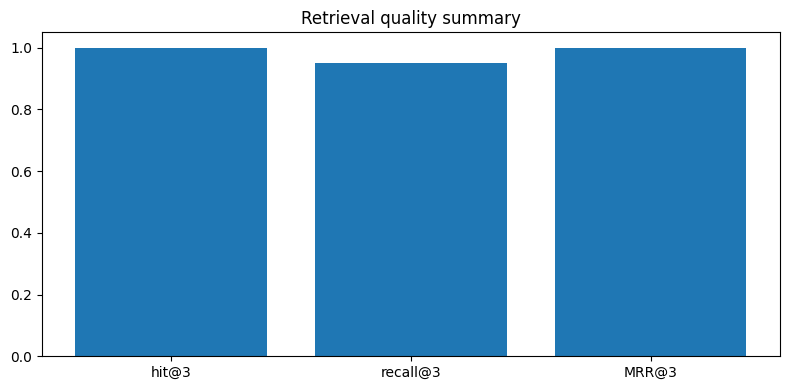

In [13]:
# Сохраняем обязательные и дополнительные артефакты
retrieval_eval.to_csv(ART_DIR / "retrieval_eval.csv", index=False)
rag_examples.to_csv(ART_DIR / "rag_examples.csv", index=False)
retrieval_before_after_update.to_csv(ART_DIR / "retrieval_before_after_update.csv", index=False)

chunks_df[["source_id", "chunk_id", "text"]].head(12).to_csv(ART_DIR / "chunk_examples.csv", index=False)

summary = {
    "seed": SEED,
    "embedding_method": "TF-IDF (word + bigram) + L2 normalization",
    "faiss_index": "IndexFlatIP",
    "similarity": "cosine via normalized inner product",
    "chunk_size": chunk_size_main,
    "overlap": overlap_main,
    "top_k": top_k_main,
    "num_documents_before_update": len(docs),
    "num_documents_after_update": len(docs_updated),
    "num_chunks_before_update": int(len(chunks_df)),
    "hit_at_k": hit_at_k,
    "recall_at_k": recall_at_k,
    "mrr_at_k": mrr_at_k,
    "chunk_size_experiment": experiment_results,
}
with open(ART_DIR / "retrieval_metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

plt.figure(figsize=(8, 4))
plt.bar(["hit@3", "recall@3", "MRR@3"], [hit_at_k, recall_at_k, mrr_at_k])
plt.ylim(0, 1.05)
plt.title("Retrieval quality summary")
plt.tight_layout()
plt.savefig(ART_DIR / "retrieval_quality_plot.png", dpi=150)
plt.show()
